# Cross-Domain Transfer Learning for Fault Detection in the Tennessee Eastman Process

**Goal:** We analyze the performance of zero-shot cross-domain evaluation across different TEP operating conditions. This approach directly measures whether the representations learned in the source domain generalize to target domains without adaptation

**Transfer-learning protocol used throughout.**
1. Train an unsupervised anomaly-detection model (a Variational Autoencoder, VAE) on the
   *Training* partition of the **source domain(s)**: fault-free-train windows + source-fault
   train windows.
2. Freeze the model. Evaluate it, with no further training, on the *Testing* partition of
   the **target domain**: fault-free-test windows + target-fault test windows.
3. The evaluation metric is ROC-AUC for separating target-domain faulty windows from
   target-domain nominal windows using the VAE's reconstruction error as an anomaly score.
4. We compare this **zero-shot cross-domain AUC** against two references:
   - an **in-domain oracle**: the same architecture trained on the target domain's own
     *training* partition and evaluated on the target domain's *testing* partition (upper
     bound, no domain shift);
   - a **generic nominal-only baseline**: a model trained only on fault-free data (no fault
     knowledge at all, like a classical process-monitoring baseline)

The gap between the zero-shot cross-domain AUC and the in-domain oracle AUC is our measure of
*how well knowledge transfers* between two fault regimes.


**Notes on reproducibility.** All random seeds are fixed. All feature-engineering and
training code is deterministic given the seed. This notebook expects the raw TEP `.RData`
files to be available locally (see Section 1) — running it end-to-end requires access to that
data, which is not bundled with the notebook itself.


## 1. Setup and Configuration

Imports, global seeds, and the folder layout used for caching intermediate artifacts
(raw data converted to CSV, and extracted feature windows). Caching is important here because
feature extraction (rolling-window statistics) is the most expensive step and is reused across
every experiment in the notebook.


In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pyreadr  # reads the original .RData TEP files

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")


current_dir = Path(os.getcwd())
base_data_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
features_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "features"

save_path.mkdir(parents=True, exist_ok=True)
features_path.mkdir(parents=True, exist_ok=True)


Using device: cpu


## 2. Data Loading

The TEP dataset ships as four `.RData` files (fault-free / faulty, training / testing). We
convert each one to CSV once and cache it, since `.RData` parsing is slow and we will reload
the data many times across a working session.


In [2]:
RAW_FILES = {
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "fault_free_test":  "TEP_FaultFree_Testing.RData",
    "faulty_train":     "TEP_Faulty_Training.RData",
    "faulty_test":      "TEP_Faulty_Testing.RData",
}

dfs = {}

for key, filename in RAW_FILES.items():
    csv_path = save_path / f"{key}.csv"
    
    if csv_path.exists():
        try:
            print(f"CSV file {key}.csv exists. Loading from CSV.")
            dfs[key] = pd.read_csv(csv_path)
            continue 
        except Exception as e:
            print(f"Warning: Failed to load {key}.csv ({e}). Proceeding to load from RData.")

    file_path = base_data_path / filename
    if file_path.exists():
        print(f"Loading {filename} (RData) in progress")
        r_data = pyreadr.read_r(file_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        
        dfs[key].to_csv(csv_path, index=False)
        print(f"File {filename} successfully converted and saved as CSV.")
    else:
        print(f"Error: Source file {filename} not found in {base_data_path}")

df_fault_free_train = dfs["fault_free_train"]
df_fault_free_test = dfs["fault_free_test"]
df_faulty_train = dfs["faulty_train"]
df_faulty_test = dfs["faulty_test"]

SENSOR_COLUMNS = [c for c in df_fault_free_train.columns
                   if c not in ("faultNumber", "simulationRun", "sample")]

print(f"\nSensor/actuator variables: {len(SENSOR_COLUMNS)}")
print(f"Fault-free train shape: {df_fault_free_train.shape}")
print(f"Fault-free test shape:  {df_fault_free_test.shape}")
print(f"Faulty train shape:     {df_faulty_train.shape}")
print(f"Faulty test shape:      {df_faulty_test.shape}")


CSV file fault_free_train.csv exists. Loading from CSV.
CSV file fault_free_test.csv exists. Loading from CSV.
CSV file faulty_train.csv exists. Loading from CSV.
CSV file faulty_test.csv exists. Loading from CSV.

Sensor/actuator variables: 52
Fault-free train shape: (250000, 55)
Fault-free test shape:  (207252, 55)
Faulty train shape:     (5000000, 55)
Faulty test shape:      (9600000, 55)


## 3. Feature Engineering: Sliding-Window Statistical Descriptors

Raw TEP samples are noisy single time steps. We summarize each process variable over a
rolling window with seven descriptive statistics (`mean, std, min, p25, p50, p75, max`),
subsampling the raw signal first to reduce autocorrelation and computational cost. Each
resulting row is one labelled observation: `52 variables × 7 statistics = 364 features`.

The **transient right after fault injection is discarded**: TEP injects the fault at sample
20 in the *Training* runs and at sample 160 in the *Testing* runs, so we drop samples before
that point, otherwise many windows would straddle the fault-free/faulty transition and get a
noisy, ambiguous label.

To mitigate the severe class imbalance inherent in the Tennessee Eastman Process (where nominal, fault-free operating windows vastly outnumber fault instances), an optional balancing strategy was introduced in build_domain_training_set. This mechanism downsamples the nominal data (Fault 0) to match the exact size of the specific fault data being incorporated into the training set. However, the results showed virtually no difference compared to the unbalanced version. This happened because the rolling-window extraction already provides a sufficient number of fault samples to train the VAE effectively, proving that the model architecture is inherently robust against class imbalance.

In [3]:
STAT_NAMES = ["mean", "std", "min", "p25", "p50", "p75", "max"]
FEATURE_NAMES = [f"{var}_{stat}" for var in SENSOR_COLUMNS for stat in STAT_NAMES]

WINDOW_SIZE = 30   # samples per rolling window
STEP = 10          # stride between consecutive windows (in subsampled units)
SUBSAMPLE = 5       # keep 1 sample every SUBSAMPLE raw samples before windowing


def extract_window_features(df_raw: pd.DataFrame, split: str,
                             window_size: int = WINDOW_SIZE,
                             step: int = STEP,
                             subsample_rate: int = SUBSAMPLE) -> tuple[np.ndarray, np.ndarray, list]:
    """Turn raw TEP samples into rolling-window statistical features.

    Parameters
    ----------
    df_raw : raw TEP dataframe (single fault number, or fault-free), one or more
        simulation runs.
    split : "train" or "test" — determines the fault-injection cutoff sample
        (20 for the official Training runs, 160 for the official Testing runs).

    Returns
    -------
    X : (n_windows, n_features) array of statistical features.
    y : (n_windows,) array with the fault number of each window (0 = fault-free).
    ids : list of string identifiers, one per window (run id + window offset).
    """
    if df_raw.empty:
        return np.array([]), np.array([]), []

    inflection_point = 20 if split == "train" else 160
    if "sample" in df_raw.columns:
        df_raw = df_raw[df_raw["sample"] > inflection_point].copy()

    df_sub = df_raw.iloc[::subsample_rate].copy()
    grouped = df_sub.groupby("simulationRun") if "simulationRun" in df_sub.columns else [(None, df_sub)]

    all_feats, all_targets, all_ids = [], [], []

    for run_id, group in grouped:
        if len(group) < window_size:
            continue

        fault_label = group["faultNumber"].iloc[0] if "faultNumber" in group.columns else 0
        rolling = group[SENSOR_COLUMNS].rolling(window=window_size)

        stat_frames = {
            "mean": rolling.mean(), "std": rolling.std(), "min": rolling.min(),
            "p25": rolling.quantile(0.25), "p50": rolling.quantile(0.50),
            "p75": rolling.quantile(0.75), "max": rolling.max(),
        }
        # Keep one row every `step` positions, starting once the window is full.
        for s_name in stat_frames:
            stat_frames[s_name] = stat_frames[s_name].iloc[window_size - 1::step]

        run_stats = pd.DataFrame({
            f"{col}_{s_name}": stat_frames[s_name][col]
            for s_name in STAT_NAMES for col in SENSOR_COLUMNS
        }).dropna()

        if run_stats.empty:
            continue

        all_feats.append(run_stats.values)
        all_targets.append(np.full(len(run_stats), fault_label))
        run_name = f"run_{run_id}" if run_id is not None else "run_all"
        all_ids.extend(f"{run_name}_w{idx * step}" for idx in range(len(run_stats)))

    if not all_feats:
        return np.array([]), np.array([]), []

    return np.vstack(all_feats), np.concatenate(all_targets), all_ids


def get_domain_features(fault_num: int, split: str) -> tuple[np.ndarray, np.ndarray]:
    """Load (from cache, or extract) the feature windows for a single fault number
    and a single official split ("train" or "test"). fault_num == 0 means fault-free.
    """
    cache_file = features_path / f"fault_{fault_num}_{split}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}.csv"
    if cache_file.exists():
        df_cached = pd.read_csv(cache_file)
        return df_cached[FEATURE_NAMES].values, df_cached["target"].values

    if fault_num == 0:
        df_raw = df_fault_free_train if split == "train" else df_fault_free_test
    else:
        df_source = df_faulty_train if split == "train" else df_faulty_test
        df_raw = df_source[df_source["faultNumber"] == fault_num]

    X, y, ids = extract_window_features(df_raw, split=split)
    if len(X) == 0:
        return np.array([]), np.array([])

    out = pd.DataFrame(X, columns=FEATURE_NAMES)
    out["target"] = y
    out["id"] = ids
    out.to_csv(cache_file, index=False)
    return X, y


# Pre-extract everything we will need: fault-free + faults 1-20, both splits.
print("Extracting / loading cached feature windows for all domains ...")
DOMAIN_FEATURES = {}  # DOMAIN_FEATURES[fault_num][split] = X
for fault_num in range(0, 21):
    DOMAIN_FEATURES[fault_num] = {}
    for split in ("train", "test"):
        X, y = get_domain_features(fault_num, split)
        DOMAIN_FEATURES[fault_num][split] = X
        print(f"  fault {fault_num:2d} [{split}]: {X.shape}")


Extracting / loading cached feature windows for all domains ...
  fault  0 [train]: (3500, 364)
  fault  0 [test]: (1, 364)
  fault  1 [train]: (3500, 364)
  fault  1 [test]: (7000, 364)
  fault  2 [train]: (3500, 364)
  fault  2 [test]: (7000, 364)
  fault  3 [train]: (3500, 364)
  fault  3 [test]: (7000, 364)
  fault  4 [train]: (3500, 364)
  fault  4 [test]: (7000, 364)
  fault  5 [train]: (3500, 364)
  fault  5 [test]: (7000, 364)
  fault  6 [train]: (3500, 364)
  fault  6 [test]: (7000, 364)
  fault  7 [train]: (3500, 364)
  fault  7 [test]: (7000, 364)
  fault  8 [train]: (3500, 364)
  fault  8 [test]: (7000, 364)
  fault  9 [train]: (3500, 364)
  fault  9 [test]: (7000, 364)
  fault 10 [train]: (3500, 364)
  fault 10 [test]: (7000, 364)
  fault 11 [train]: (3500, 364)
  fault 11 [test]: (7000, 364)
  fault 12 [train]: (3500, 364)
  fault 12 [test]: (7000, 364)
  fault 13 [train]: (3500, 364)
  fault 13 [test]: (7000, 364)
  fault 14 [train]: (3500, 364)
  fault 14 [test]: (7000,

## 4. Model: Variational Autoencoder for Process Monitoring

Model Architecture. We use a standard VAE across all experiments. It is trained to reconstruct normal operating data, using reconstruction error (MSE) as the anomaly score. Because it is never trained for explicit classification, it generalizes naturally to unseen faults. A single, unified architecture is used for all subsequent tasks.

Standard VAE implementations typically use $\beta = 1.0$. However, in our TEP experiments, this standard value caused severe over-regularization, flattening the latent space and forcing the variance close to zero (posterior collapse). Under this condition, the decoder ignored the latent variables and failed to capture subtle anomaly signatures. To prevent this, $\beta$ was relaxed to $0.5$, providing a better trade-off between latent space regularity and reconstruction fidelity.


In [ ]:
class TEPVariationalAutoencoder(nn.Module):
    """VAE used to learn the nominal operating envelope (or, in the transfer
    experiments, the joint envelope of nominal + a chosen set of source faults).
    """

    def __init__(self, input_dim: int, latent_dim: int = 16,
                 hidden_dims: tuple = (64, 32), dropout: float = 0.1):
        super().__init__()

        enc_layers, prev_dim = [], input_dim
        for h in hidden_dims:
            enc_layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.LeakyReLU(0.2), nn.Dropout(dropout)]
            prev_dim = h
        self.encoder_body = nn.Sequential(*enc_layers)
        self.mu_head = nn.Linear(hidden_dims[-1], latent_dim)
        self.logvar_head = nn.Linear(hidden_dims[-1], latent_dim)

        dec_layers, prev_dim = [], latent_dim
        for h in reversed(hidden_dims):
            dec_layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.LeakyReLU(0.2), nn.Dropout(dropout)]
            prev_dim = h
        dec_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x):
        h = self.encoder_body(x)
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


def vae_loss(x, x_recon, mu, logvar, beta: float = 0.2):
    recon = F.mse_loss(x_recon, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl


def train_vae(X_scaled: np.ndarray, latent_dim: int = 16, hidden_dims=(64, 32),
              epochs: int = 30, lr: float = 1e-3, batch_size: int = 64,
              beta: float = 1.0, verbose: bool = False) -> TEPVariationalAutoencoder:
    """Train a fresh VAE on the given (already standardized) feature matrix."""
    model = TEPVariationalAutoencoder(input_dim=X_scaled.shape[1],
                                       latent_dim=latent_dim,
                                       hidden_dims=hidden_dims).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(torch.tensor(X_scaled, dtype=torch.float32)),
                         batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for (batch_x,) in loader:
            batch_x = batch_x.to(DEVICE)
            optimizer.zero_grad()
            recon_x, mu, logvar = model(batch_x)
            loss, _, _ = vae_loss(batch_x, recon_x, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if verbose and (epoch % max(1, epochs // 5) == 0 or epoch == 1):
            print(f"    epoch {epoch:3d}/{epochs} | ELBO: {epoch_loss / len(loader):.4f}")

    return model


@torch.no_grad()
def reconstruction_error(model: TEPVariationalAutoencoder, X_scaled: np.ndarray) -> np.ndarray:
    """Per-sample MSE reconstruction error (the anomaly score)."""
    model.eval()
    x = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
    recon, _, _ = model(x)
    return torch.mean((x - recon) ** 2, dim=1).cpu().numpy()


## 5. Baseline: In-Domain Global Fault-Detection Performance

Before studying transfer, we need a reference point: how well does a *classical*
process-monitoring model perform when trained and evaluated in the ordinary way (train on
fault-free data only, then detect any of the 20 faults as "anomalous")? All subsequent
transfer results are read relative to this baseline.


In [50]:
X_free_train = DOMAIN_FEATURES[0]["train"]
X_free_test = DOMAIN_FEATURES[0]["test"]

scaler = StandardScaler().fit(X_free_train)
X_free_train_scaled = scaler.transform(X_free_train)
X_free_test_scaled = scaler.transform(X_free_test)


nominal_vae = train_vae(X_free_train_scaled, latent_dim=12, hidden_dims=(64, 32),
                         epochs=100, lr=1e-3, verbose=True, beta=0.5)

mse_free_test = reconstruction_error(nominal_vae, X_free_test_scaled)

per_fault_results = []
for fault_num in range(1, 21):
    X_fault_test = DOMAIN_FEATURES[fault_num]["test"]
    if len(X_fault_test) == 0:
        continue
    X_fault_test_scaled = scaler.transform(X_fault_test)
    mse_fault = reconstruction_error(nominal_vae, X_fault_test_scaled)

    y_true = np.concatenate([np.zeros(len(mse_free_test)), np.ones(len(mse_fault))])
    y_score = np.concatenate([mse_free_test, mse_fault])
    auc = roc_auc_score(y_true, y_score)

    threshold_99 = np.percentile(mse_free_test, 99)
    detection_rate = (mse_fault > threshold_99).mean() * 100

    per_fault_results.append({"Fault": f"F{fault_num}", "ROC_AUC": auc,
                               "Detection_Rate_%": detection_rate})

baseline_df = pd.DataFrame(per_fault_results)
global_auc = roc_auc_score(
    np.concatenate([np.zeros(len(mse_free_test)),
                     np.ones(sum(len(DOMAIN_FEATURES[f]["test"]) for f in range(1, 21)))]),
    np.concatenate([mse_free_test] + [reconstruction_error(nominal_vae, scaler.transform(DOMAIN_FEATURES[f]["test"]))
                                        for f in range(1, 21)]),
)
print(f"\nGlobal nominal-only ROC-AUC (all faults pooled): {global_auc:.4f}")
baseline_df


    epoch   1/100 | ELBO: 1.1088
    epoch  20/100 | ELBO: 0.9366
    epoch  40/100 | ELBO: 0.9334
    epoch  60/100 | ELBO: 0.9311
    epoch  80/100 | ELBO: 0.9319
    epoch 100/100 | ELBO: 0.9332

Global nominal-only ROC-AUC (all faults pooled): 0.8446


,Fault,ROC_AUC,Detection_Rate_%
0,F1,1.000000,100.000000
1,F2,1.000000,100.000000
2,F3,0.121429,12.142857
3,F4,1.000000,100.000000
4,F5,1.000000,100.000000
5,F6,1.000000,100.000000
6,F7,1.000000,100.000000
7,F8,1.000000,100.000000
8,F9,0.102000,10.200000
9,F10,0.890286,89.028571


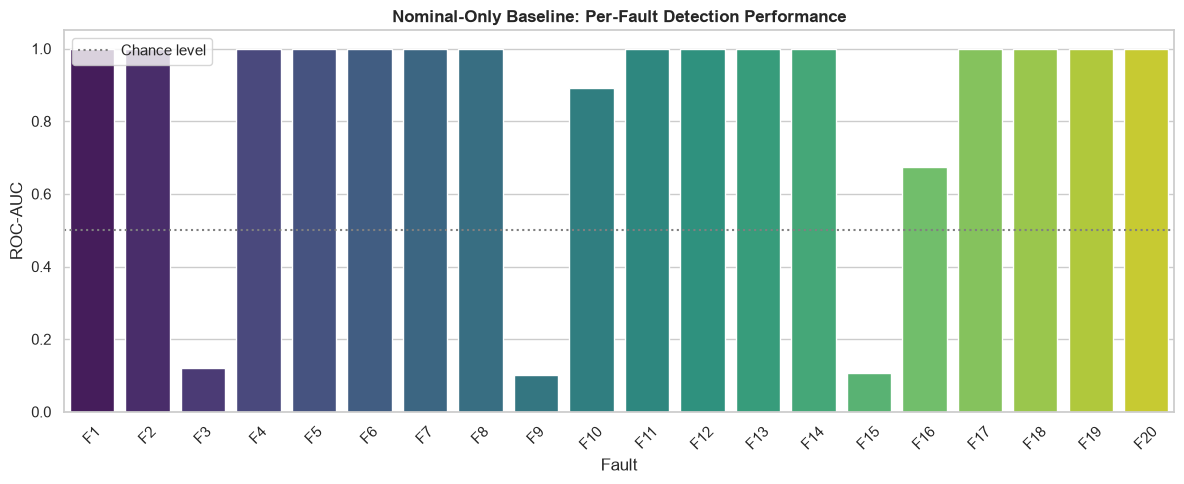

In [51]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=baseline_df, x="Fault", y="ROC_AUC", hue="Fault", palette="viridis",
            legend=False, ax=ax)
ax.axhline(0.5, color="gray", linestyle=":", label="Chance level")
ax.set_title("Nominal-Only Baseline: Per-Fault Detection Performance", fontweight="bold")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Transfer-Learning Framework

We now implement the core protocol described in the introduction.

For a scenario with **source fault(s)** `S` and a **target fault** `T`:

| Model | Trained on | Evaluated on | Role |
|---|---|---|---|
| Source-domain model | fault-free-**train** + fault(s) `S`-**train** | fault-free-**test** + fault `T`-**test** | zero-shot cross-domain transfer |
| In-domain oracle | fault-free-**train** + fault `T`-**train** | fault-free-**test** + fault `T`-**test** | upper bound (no domain shift) |
| Nominal-only baseline | fault-free-**train** | fault-free-**test** + fault `T`-**test** | lower-reference (no fault knowledge at all, from Section 5) |

The **transfer ratio** `AUC(source→target) / AUC(target→target)` summarizes how much of the
achievable (in-domain) performance is recovered zero-shot. A ratio near 1 indicates that the
representation learned on the source fault(s) generalizes almost perfectly to the target
fault; a ratio near `AUC(nominal-only)/AUC(target→target)` indicates essentially no transfer
beyond what a generic nominal model already provides.


In [ ]:
def build_domain_training_set(fault_ids: list, balance: bool = True, seed: int = SEED) -> np.ndarray:
    """Fault-free-train windows + train-split windows of the given fault ids,
    concatenated to represent one source domain's training experience, with optional balancing."""
    
    # 1. Raccogliamo i dati dei fault richiesti
    fault_parts = [DOMAIN_FEATURES[f]["train"] for f in fault_ids if f in DOMAIN_FEATURES and len(DOMAIN_FEATURES[f]["train"]) > 0]
    if not fault_parts:
        return DOMAIN_FEATURES[0]["train"]
        
    X_fault = np.vstack(fault_parts)
    X_free = DOMAIN_FEATURES[0]["train"]
    
    if balance and len(X_free) > len(X_fault):
        idx = np.random.default_rng(seed).choice(len(X_free), size=len(X_fault), replace=False)
        X_free = X_free[idx]
        
    # 3. Concatenazione finale identica alla tua versione
    return np.vstack([X_free, X_fault])


def evaluate_on_target(model: TEPVariationalAutoencoder, target_fault: int) -> dict:
    """Zero-shot evaluation of `model` on the *test* split of a target domain."""
    X_target_test = DOMAIN_FEATURES[target_fault]["test"]
    X_target_scaled = scaler.transform(X_target_test)
    mse_target = reconstruction_error(model, X_target_scaled)

    y_true = np.concatenate([np.zeros(len(mse_free_test)), np.ones(len(mse_target))])
    y_score = np.concatenate([mse_free_test, mse_target])
    auc = roc_auc_score(y_true, y_score)
    return {"AUC": auc, "mean_MSE_target": mse_target.mean()}


def run_transfer_scenario(source_faults: list, target_fault: int,
                           epochs: int = 30, latent_dim: int = 16, balance: bool = True) -> dict:
    """Train a fresh VAE on `source_faults` (train split) and evaluate it
    zero-shot on `target_fault` (test split). Also trains the in-domain oracle
    for the same target fault, for reference."""
    set_seed(SEED)

    # --- Source-domain model (zero-shot transfer) ---
    X_source_scaled = scaler.transform(build_domain_training_set(source_faults, balance=balance, seed=SEED))
    source_model = train_vae(X_source_scaled, latent_dim=latent_dim, epochs=epochs, beta=0.5)
    transfer_metrics = evaluate_on_target(source_model, target_fault)

    # --- In-domain oracle (trained directly on the target fault) ---
    X_oracle_scaled = scaler.transform(build_domain_training_set([target_fault], balance=balance, seed=SEED))
    oracle_model = train_vae(X_oracle_scaled, latent_dim=latent_dim, epochs=epochs, beta=0.2)
    oracle_metrics = evaluate_on_target(oracle_model, target_fault)

    transfer_ratio = (transfer_metrics["AUC"] / oracle_metrics["AUC"]
                       if oracle_metrics["AUC"] > 0 else np.nan)

    return {
        "Source": "+".join(f"F{s}" for s in source_faults),
        "Target": f"F{target_fault}",
        "AUC_transfer": transfer_metrics["AUC"],
        "AUC_in_domain_oracle": oracle_metrics["AUC"],
        "Transfer_ratio": transfer_ratio,
    }


## 7. Experiment A — One-to-One Zero-Shot Transfer

Each scenario trains on a *single* source fault and evaluates, with no adaptation, on a
different *single* target fault. The pairs mix faults that are physically related (e.g. two
feed-composition faults) with pairs that are physically unrelated, to see whether transfer
tracks physical similarity.


In [61]:
one_to_one_scenarios = {
    "F1 -> F2":   {"source": [1], "target": 2},    # both feed-composition faults
    "F2 -> F6":   {"source": [2], "target": 6},    # feed composition -> feed loss
    "F6 -> F10":  {"source": [6], "target": 10},   # feed loss -> feed temperature/kinetics
    "F1 -> F18":  {"source": [1], "target": 18},   # feed -> reaction kinetics (unrelated)
    "F2 -> F8":   {"source": [2], "target": 8},    # feed composition -> feed composition (related)
    "F4 -> F5":   {"source": [4], "target": 5},    # both cooling-water faults (related)
    "F3 -> F10":  {"source": [3], "target": 10},   # feed temperature -> kinetics (weakly related)
    "F4 -> F14":  {"source": [4], "target": 14},   # cooling water -> valve sticking (unrelated)
}

one_to_one_results = [
    run_transfer_scenario(cfg["source"], cfg["target"])
    for name, cfg in one_to_one_scenarios.items()
]
for row, name in zip(one_to_one_results, one_to_one_scenarios):
    row["Scenario"] = name

df_one_to_one = pd.DataFrame(one_to_one_results)[
    ["Scenario", "Source", "Target", "AUC_transfer", "AUC_in_domain_oracle", "Transfer_ratio"]
]
df_one_to_one


,Scenario,Source,Target,AUC_transfer,AUC_in_domain_oracle,Transfer_ratio
0,F1 -> F2,F1,F2,1.000000,0.988143,1.011999
1,F2 -> F6,F2,F6,1.000000,1.000000,1.000000
2,F6 -> F10,F6,F10,0.973714,0.360143,2.703689
3,F1 -> F18,F1,F18,1.000000,1.000000,1.000000
4,F2 -> F8,F2,F8,1.000000,1.000000,1.000000
5,F4 -> F5,F4,F5,1.000000,0.263143,3.800217
6,F3 -> F10,F3,F10,0.890857,0.360143,2.473622
7,F4 -> F14,F4,F14,1.000000,0.986857,1.013318


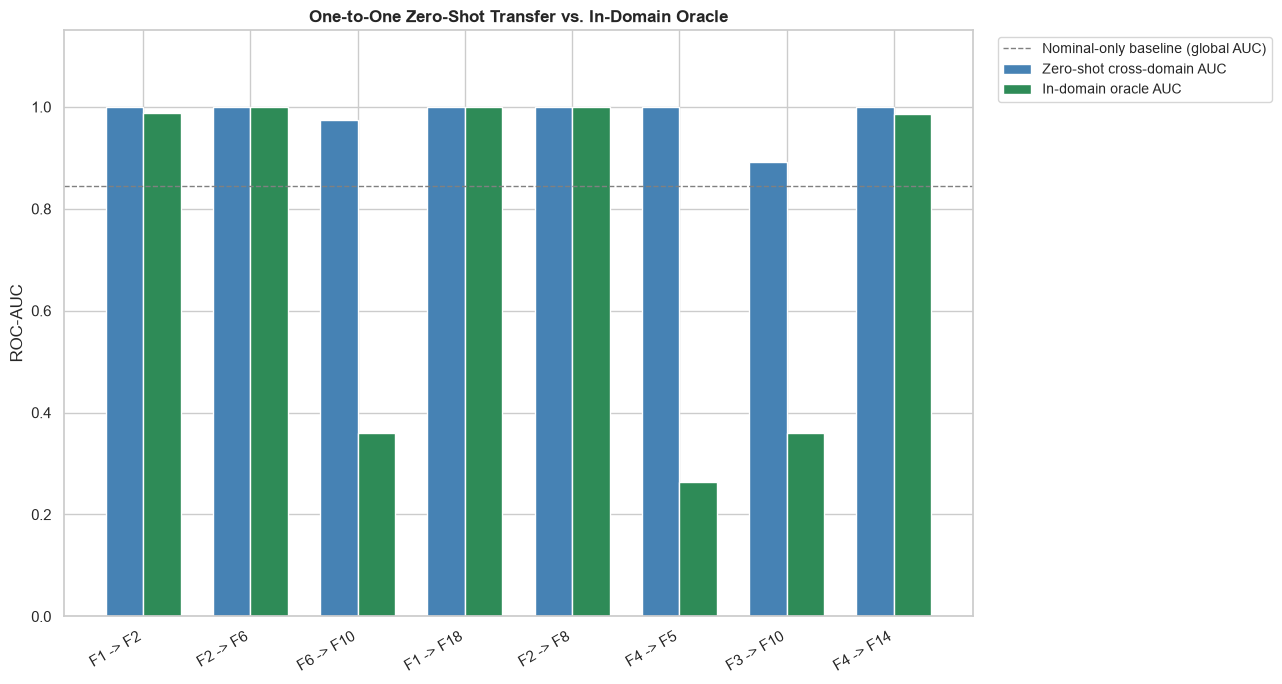

In [62]:
fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(df_one_to_one))
width = 0.35

ax.bar(x - width / 2, df_one_to_one["AUC_transfer"], width,
       label="Zero-shot cross-domain AUC", color="steelblue")
ax.bar(x + width / 2, df_one_to_one["AUC_in_domain_oracle"], width,
       label="In-domain oracle AUC", color="seagreen")

ax.axhline(global_auc, color="gray", linestyle="--", linewidth=1,
           label="Nominal-only baseline (global AUC)")

ax.set_xticks(x)
ax.set_xticklabels(df_one_to_one["Scenario"], rotation=30, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.15) # Esteso leggermente per lasciare spazio alla legenda esterna senza tagliare nulla
ax.set_title("One-to-One Zero-Shot Transfer vs. In-Domain Oracle", fontweight="bold")

# Spostiamo la legenda all'esterno sulla destra per non coprire le barre
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)

plt.tight_layout()
plt.show()


## 8. Experiment B — Many-to-One Zero-Shot Transfer

Here the source domain is built from *several* faults that share a plausible physical
mechanism (e.g. all feed-related faults), and we test whether the resulting model transfers
better to a *related* target fault (Group 1) than to an *unrelated* one (Group 2, the control
condition). If transfer learning is capturing genuine shared structure, Group 1 should show
higher `Transfer_ratio` than Group 2.


In [ ]:
many_to_one_scenarios = {
    # Group 1: coherent scenarios (related source group -> related target)
    "(F1,F2) -> F6": {"source": [1, 2], "target": 6},  # feed group
    "(F4,F5) -> F11": {"source": [4, 5], "target": 11},  # thermal group
    "(F13,F14,F15) -> F18": {"source": [13, 14, 15], "target": 18},  # actuator group

    # Group 2: control scenarios (related source group -> unrelated target)
    "(F1,F2) -> F15": {"source": [1, 2], "target": 15},  # feed group -> mechanical
    "(F4,F5) -> F3": {"source": [4, 5], "target": 3},  # thermal group -> feed
    "(F6,F7) -> F10":  {"source": [6, 7], "target": 10},  # pressure group -> kinetics
}

many_to_one_results = [
    run_transfer_scenario(cfg["source"], cfg["target"],balance=False)
    for name, cfg in many_to_one_scenarios.items()
]
for row, name in zip(many_to_one_results, many_to_one_scenarios):
    row["Scenario"] = name
    row["Group"] = "Coherent (related)" if name.startswith(tuple(list(many_to_one_scenarios)[:3])) else "Control (unrelated)"

df_many_to_one = pd.DataFrame(many_to_one_results)[
    ["Scenario", "Group", "Source", "Target", "AUC_transfer", "AUC_in_domain_oracle", "Transfer_ratio"]
]
df_many_to_one


,Scenario,Group,Source,Target,AUC_transfer,AUC_in_domain_oracle,Transfer_ratio
0,"(F1,F2) -> F6",Coherent (related),F1+F2,F6,1.000000,1.000000,1.000000
1,"(F4,F5) -> F11",Coherent (related),F4+F5,F11,1.000000,0.684000,1.461988
2,"(F13,F14,F15) -> F18",Coherent (related),F13+F14+F15,F18,1.000000,1.000000,1.000000
3,"(F1,F2) -> F15",Control (unrelated),F1+F2,F15,0.394714,0.026857,14.696809
4,"(F4,F5) -> F3",Control (unrelated),F4+F5,F3,0.135429,0.025286,5.355932
5,"(F6,F7) -> F10",Control (unrelated),F6+F7,F10,1.000000,0.465143,2.149877


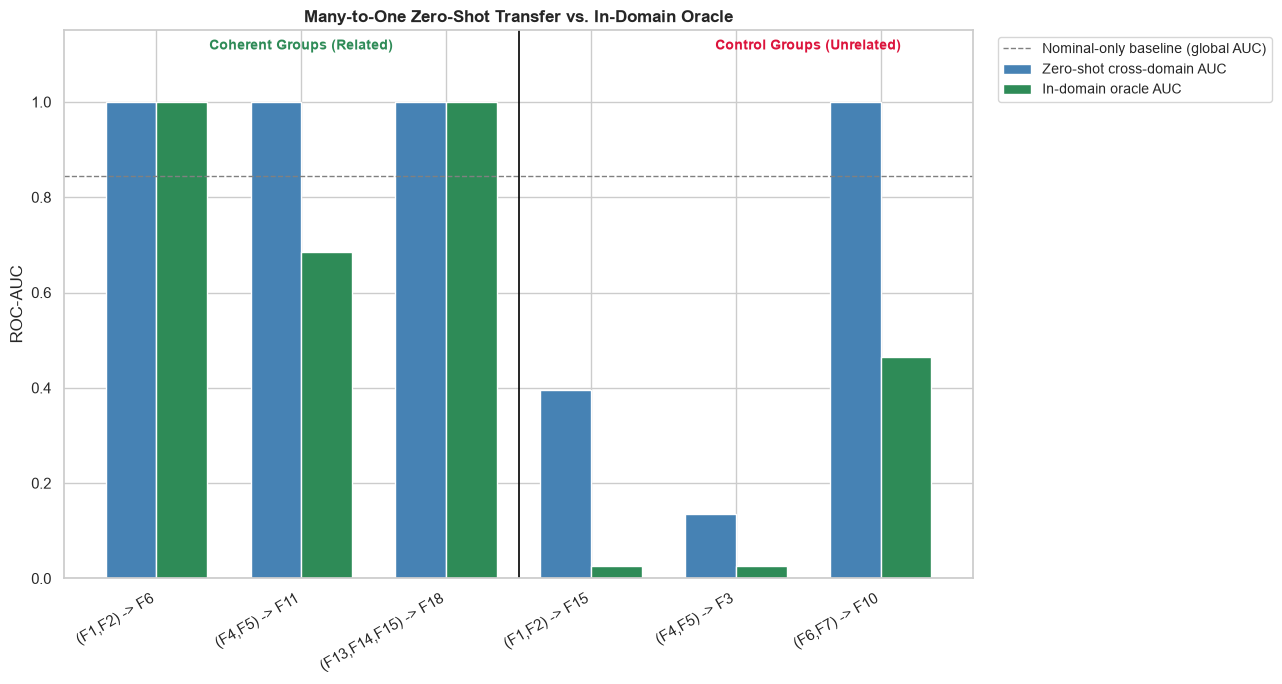

In [64]:
fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(df_many_to_one))
width = 0.35

ax.bar(x - width / 2, df_many_to_one["AUC_transfer"], width,
       label="Zero-shot cross-domain AUC", color="steelblue")
ax.bar(x + width / 2, df_many_to_one["AUC_in_domain_oracle"], width,
       label="In-domain oracle AUC", color="seagreen")

ax.axhline(global_auc, color="gray", linestyle="--", linewidth=1,
           label="Nominal-only baseline (global AUC)")

ax.set_xticks(x)
ax.set_xticklabels(df_many_to_one["Scenario"], rotation=30, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.15)
ax.set_title("Many-to-One Zero-Shot Transfer vs. In-Domain Oracle", fontweight="bold")

split_idx = 2.5 
ax.axvline(split_idx, color="black", linestyle="-", linewidth=1.2)

# Etichette superiori dei gruppi
ax.text(1, 1.11, "Coherent Groups (Related)", ha="center", fontweight="bold", fontsize=10, color="seagreen")
ax.text(4.5, 1.11, "Control Groups (Unrelated)", ha="center", fontweight="bold", fontsize=10, color="crimson")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)

plt.tight_layout()
plt.show()

## 9. Full Pairwise Transfer Matrix (Systematic Analysis)

The scenarios above are hand-picked and therefore anecdotal. To make the analysis rigorous we
run the **same zero-shot protocol for every ordered pair of faults** (source ≠ target) over a
subset of faults `PAIRWISE_FAULTS`. Note that this only requires training one VAE per faul.
The result is a transfer-ratio heatmap that lets us look for clusters of mutually-transferable faults instead of relying on a handful of examples.

In [ ]:
PAIRWISE_FAULTS = [1, 2, 3, 4, 5, 6, 7, 8, 10, 11]  # extend to list(range(1, 21)) for the full matrix

pairwise_records = []
oracle_auc_cache = {}

for target in PAIRWISE_FAULTS:
    if target not in oracle_auc_cache:
        X_oracle_scaled = scaler.transform(build_domain_training_set([target], balance=False, seed=SEED))
        oracle_model = train_vae(X_oracle_scaled, latent_dim=16, epochs=30)
        oracle_auc_cache[target] = evaluate_on_target(oracle_model, target)["AUC"]

    for source in PAIRWISE_FAULTS:
        if source == target:
            continue
        set_seed(SEED)
        X_source_scaled = scaler.transform(build_domain_training_set([source], balance=False, seed=SEED))
        source_model = train_vae(X_source_scaled, latent_dim=16, epochs=30)
        auc_transfer = evaluate_on_target(source_model, target)["AUC"]
        ratio = auc_transfer / oracle_auc_cache[target] if oracle_auc_cache[target] > 0 else np.nan

        pairwise_records.append({
            "Source": source, "Target": target,
            "AUC_transfer": auc_transfer, "Transfer_ratio": ratio,
        })
    print(f"Target F{target} done (in-domain oracle AUC = {oracle_auc_cache[target]:.3f})")

df_pairwise = pd.DataFrame(pairwise_records)
matrix = df_pairwise.pivot(index="Source", columns="Target", values="Transfer_ratio")
matrix


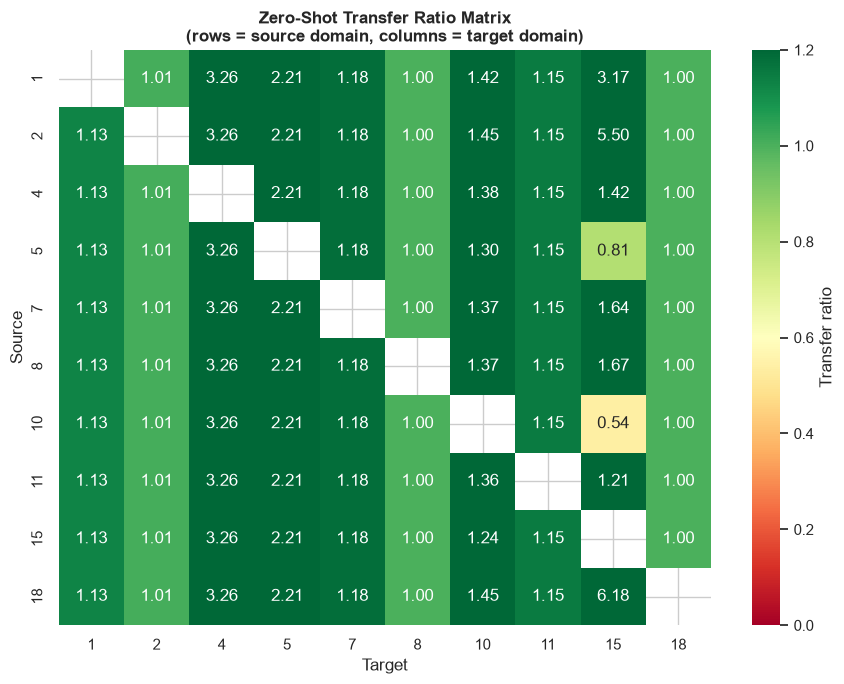

In [69]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1.2,
            cbar_kws={"label": "Transfer ratio"}, ax=ax)
ax.set_title("Zero-Shot Transfer Ratio Matrix\n(rows = source domain, columns = target domain)",
             fontweight="bold")
plt.tight_layout()
plt.show()


## 10.Fine-Tuning-Based Domain Adaptation (For Comparison Only)
It is included only as a contrasting baseline: fine-tuning should always match or
beat zero-shot transfer, and comparing the size of that gap is informative: a small gap means
the source model was already close to optimal for the target domain; a large gap means
substantial target-specific adaptation was needed.


In [ ]:
def run_finetuning_scenario(source_faults: list, target_fault: int,
                             pretrain_epochs: int = 15, finetune_epochs: int = 10,
                             finetune_lr: float = 1e-5, latent_dim: int = 16, balance: bool = True, beta: float = 0.5) -> dict:
    set_seed(SEED)
    X_source_scaled = scaler.transform(build_domain_training_set(source_faults, balance=balance, seed=SEED))
    model = train_vae(X_source_scaled, latent_dim=latent_dim, epochs=pretrain_epochs, beta=beta)
    pre_auc = evaluate_on_target(model, target_fault)["AUC"]

    # Fine-tune on the target domain's own training split, low learning rate.
    X_target_train_scaled = scaler.transform(build_domain_training_set([target_fault], balance=balance, seed=SEED))
    loader = DataLoader(TensorDataset(torch.tensor(X_target_train_scaled, dtype=torch.float32)),
                         batch_size=64, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=finetune_lr)
    model.train()
    for _ in range(finetune_epochs):
        for (bx,) in loader:
            bx = bx.to(DEVICE)
            optimizer.zero_grad()
            recon_x, mu, logvar = model(bx)
            loss, _, _ = vae_loss(bx, recon_x, mu, logvar, beta=0.01)
            loss.backward()
            optimizer.step()

    post_auc = evaluate_on_target(model, target_fault)["AUC"]

    return {"Source": "+".join(f"F{s}" for s in source_faults), "Target": f"F{target_fault}",
            "AUC_zero_shot": pre_auc, "AUC_fine_tuned": post_auc}


finetune_scenarios = many_to_one_scenarios  # reuse the same source/target groups as Section 8
finetune_results = [
    run_finetuning_scenario(cfg["source"], cfg["target"])
    for cfg in finetune_scenarios.values()
]
for row, name in zip(finetune_results, finetune_scenarios):
    row["Scenario"] = name

df_finetune = pd.DataFrame(finetune_results)[
    ["Scenario", "Source", "Target", "AUC_zero_shot", "AUC_fine_tuned"]
]
df_finetune


,Scenario,Source,Target,AUC_zero_shot,AUC_fine_tuned
0,"(F1,F2) -> F6",F1+F2,F6,1.000000,1.000000
1,"(F4,F5) -> F11",F4+F5,F11,1.000000,1.000000
2,"(F13,F14,F15) -> F18",F13+F14+F15,F18,1.000000,1.000000
3,"(F1,F2) -> F15",F1+F2,F15,0.539714,0.995857
4,"(F4,F5) -> F3",F4+F5,F3,0.375429,0.907000
5,"(F6,F7) -> F10",F6+F7,F10,1.000000,1.000000


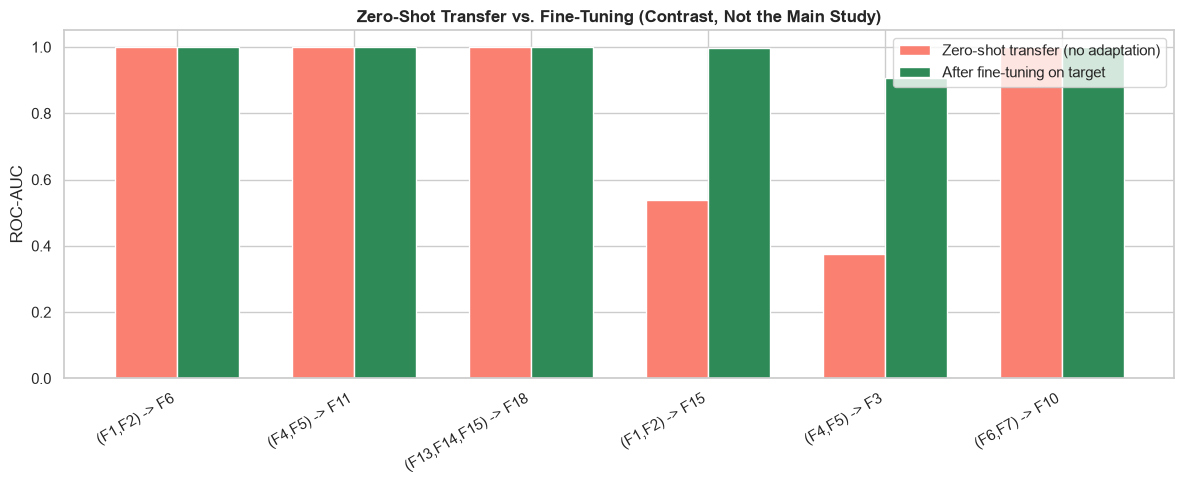

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_finetune))
width = 0.35
ax.bar(x - width / 2, df_finetune["AUC_zero_shot"], width,
       label="Zero-shot transfer (no adaptation)", color="salmon")
ax.bar(x + width / 2, df_finetune["AUC_fine_tuned"], width,
       label="After fine-tuning on target", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(df_finetune["Scenario"], rotation=30, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.05)
ax.set_title("Zero-Shot Transfer vs. Fine-Tuning (Contrast, Not the Main Study)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
